# Structured Soil Data — Exploratory Data Analysis

This notebook performs exploratory data analysis on the structured soil and
crop dataset used in the project.

## Objectives

- Load and verify the structured dataset
- Inspect dataset dimensions, columns, and data types
- Check missing values and duplicate records
- Analyze numerical feature distributions
- Examine coded categorical features
- Study relationships between numerical variables
- Analyze soil nutrient and pH characteristics across crops
- Examine the distribution of crops across soil types

The findings from this EDA are used to understand the available features and
support the feature preparation and machine-learning workflow in the
subsequent structured-data modeling notebook.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
DATA_PATH = "/content/drive/MyDrive/Soil_Analytics_Project/Data/Raw/Structured_Data/Crop_recommendationV2.csv"

print("Dataset exists:", os.path.exists(DATA_PATH))

Dataset exists: True


In [ ]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (2200, 23)


In [ ]:
print("Dataset Columns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Columns:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label', 'soil_moisture', 'soil_type', 'sunlight_exposure', 'wind_speed', 'co2_concentration', 'organic_matter', 'irrigation_frequency', 'crop_density', 'pest_pressure', 'fertilizer_usage', 'growth_stage', 'urban_area_proximity', 'water_source_type', 'frost_risk', 'water_usage_efficiency']

First 5 Rows:


,N,P,K,temperature,humidity,ph,rainfall,label,soil_moisture,soil_type,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,29.446064,2,...,3.121395,4,11.743910,57.607308,188.194958,1,2.719614,3,95.649985,1.193293
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,12.851183,3,...,2.142021,4,16.797101,74.736879,70.963629,1,4.714427,2,77.265694,1.752672
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,29.363913,2,...,1.474974,1,12.654395,1.034478,191.976077,1,30.431736,2,18.192168,3.035541
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,26.207732,3,...,8.393907,1,10.864360,24.091888,55.761388,3,10.861071,3,82.818720,1.273341
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,28.236236,2,...,5.202285,3,13.852910,38.811481,185.259702,2,47.190777,3,25.466499,2.578671


In [ ]:
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   N                       2200 non-null   int64  
 1   P                       2200 non-null   int64  
 2   K                       2200 non-null   int64  
 3   temperature             2200 non-null   float64
 4   humidity                2200 non-null   float64
 5   ph                      2200 non-null   float64
 6   rainfall                2200 non-null   float64
 7   label                   2200 non-null   object 
 8   soil_moisture           2200 non-null   float64
 9   soil_type               2200 non-null   int64  
 10  sunlight_exposure       2200 non-null   float64
 11  wind_speed              2200 non-null   float64
 12  co2_concentration       2200 non-null   float64
 13  organic_matter          2200 non-null   float64
 14  irrigation_frequency

In [ ]:
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing_values = df.isnull().sum()
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

MISSING VALUES
N                         0
P                         0
K                         0
temperature               0
humidity                  0
ph                        0
rainfall                  0
label                     0
soil_moisture             0
soil_type                 0
sunlight_exposure         0
wind_speed                0
co2_concentration         0
organic_matter            0
irrigation_frequency      0
crop_density              0
pest_pressure             0
fertilizer_usage          0
growth_stage              0
urban_area_proximity      0
water_source_type         0
frost_risk                0
water_usage_efficiency    0
dtype: int64

Total missing values: 0


In [ ]:
print("=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

DUPLICATE CHECK
Duplicate rows: 0


In [ ]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

display(df.describe())

DESCRIPTIVE STATISTICS


,N,P,K,temperature,humidity,ph,rainfall,soil_moisture,soil_type,sunlight_exposure,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,...,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655,20.151388,1.991364,8.570609,...,5.465652,3.515000,12.344959,49.850701,125.846403,1.999545,24.801013,2.003636,50.304701,2.990268
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389,5.793720,0.812263,1.999382,...,2.605294,1.697912,4.297494,28.886354,43.564527,0.818999,14.523975,0.812021,28.580352,1.139637
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,10.024260,1.000000,5.000710,...,1.003338,1.000000,5.004341,0.038103,50.209990,1.000000,0.017756,1.000000,0.054911,1.002106
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686,15.179949,1.000000,6.904620,...,3.203903,2.000000,8.585734,24.379866,88.030737,1.000000,12.212594,1.000000,26.104674,2.051814
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624,20.088481,2.000000,8.609968,...,5.418049,4.000000,12.303616,49.982421,126.441536,2.000000,24.922548,2.000000,50.171934,2.968675
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508,25.255146,3.000000,10.220394,...,7.686417,5.000000,15.975567,74.681904,163.850536,3.000000,37.322761,3.000000,75.262676,3.968736
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,29.997860,3.000000,11.991041,...,9.999990,6.000000,19.988474,99.983849,199.982166,3.000000,49.992046,3.000000,99.957274,4.997130


In [ ]:
print("=" * 60)
print("FEATURE TYPES")
print("=" * 60)

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

FEATURE TYPES
Numerical columns:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'soil_moisture', 'soil_type', 'sunlight_exposure', 'wind_speed', 'co2_concentration', 'organic_matter', 'irrigation_frequency', 'crop_density', 'pest_pressure', 'fertilizer_usage', 'growth_stage', 'urban_area_proximity', 'water_source_type', 'frost_risk', 'water_usage_efficiency']

Categorical columns:
['label']


In [ ]:
print("=" * 60)
print("CROP LABEL DISTRIBUTION")
print("=" * 60)

label_counts = df['label'].value_counts()

print("Number of crop classes:", df['label'].nunique())
print("\nSamples per crop:")
display(label_counts)

CROP LABEL DISTRIBUTION
Number of crop classes: 22

Samples per crop:


,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


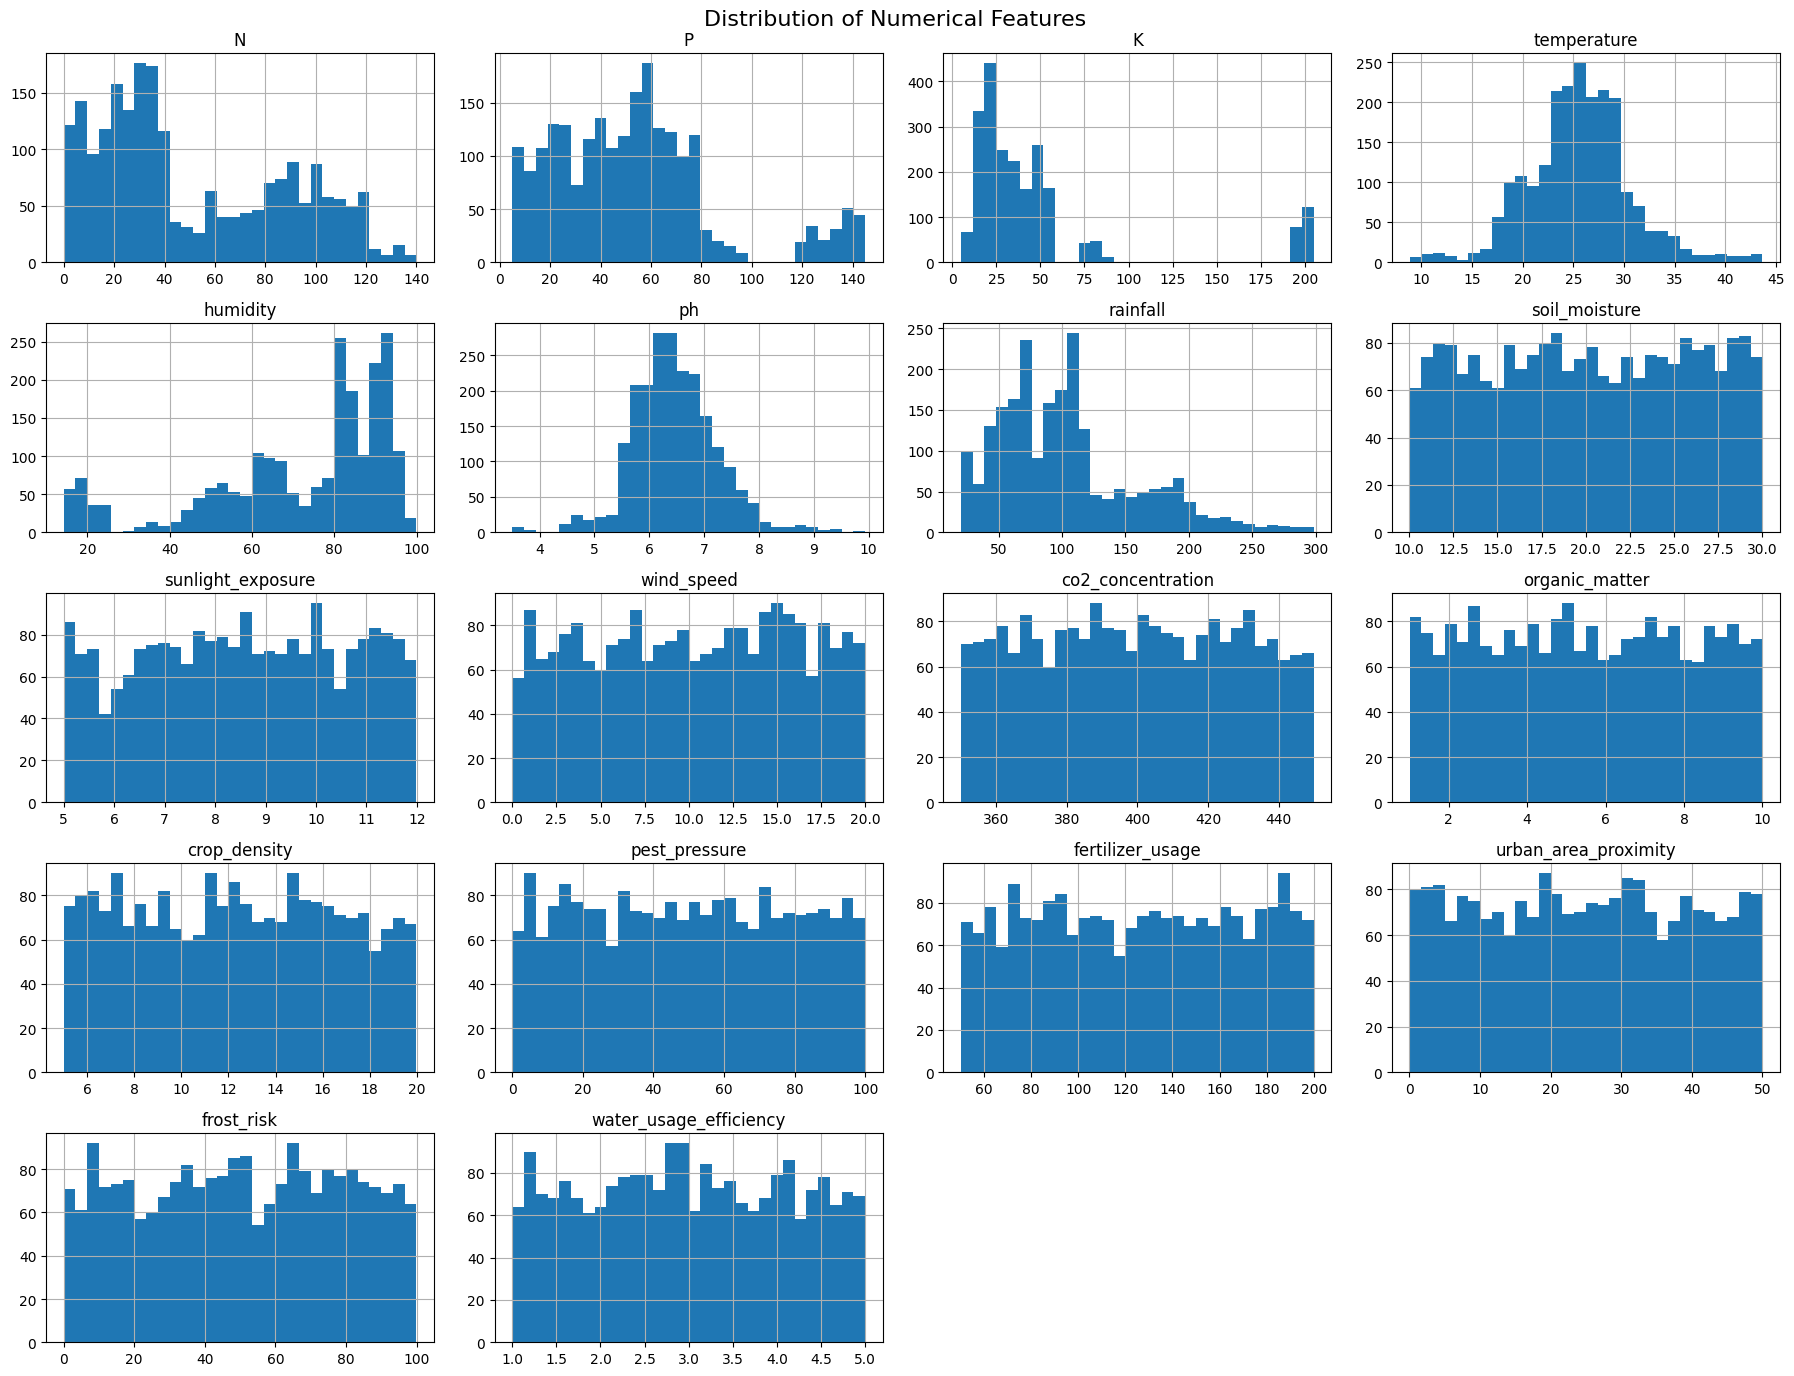

In [ ]:
numerical_cols = [
    'N',
    'P',
    'K',
    'temperature',
    'humidity',
    'ph',
    'rainfall',
    'soil_moisture',
    'sunlight_exposure',
    'wind_speed',
    'co2_concentration',
    'organic_matter',
    'crop_density',
    'pest_pressure',
    'fertilizer_usage',
    'urban_area_proximity',
    'frost_risk',
    'water_usage_efficiency'
]

df[numerical_cols].hist(figsize=(18, 14), bins=30)

plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("CATEGORICAL FEATURE DISTRIBUTIONS")
print("=" * 60)

coded_categorical_cols = [
    'soil_type',
    'irrigation_frequency',
    'growth_stage',
    'water_source_type'
]

for col in coded_categorical_cols:
    print(f"\n{col}")
    print("-" * 40)
    print("Unique values:", df[col].nunique())
    display(df[col].value_counts().sort_index())

CATEGORICAL FEATURE DISTRIBUTIONS

soil_type
----------------------------------------
Unique values: 3


,count
soil_type,
1,735
2,749
3,716



irrigation_frequency
----------------------------------------
Unique values: 6


,count
irrigation_frequency,
1,366
2,348
3,361
4,398
5,366
6,361



growth_stage
----------------------------------------
Unique values: 3


,count
growth_stage,
1,738
2,725
3,737



water_source_type
----------------------------------------
Unique values: 3


,count
water_source_type,
1,721
2,750
3,729


In [ ]:
print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

correlation_matrix = df[numerical_cols].corr()

display(correlation_matrix.round(3))

CORRELATION ANALYSIS


,N,P,K,temperature,humidity,ph,rainfall,soil_moisture,sunlight_exposure,wind_speed,co2_concentration,organic_matter,crop_density,pest_pressure,fertilizer_usage,urban_area_proximity,frost_risk,water_usage_efficiency
N,1.000,-0.231,-0.141,0.027,0.191,0.097,0.059,-0.031,0.005,0.068,-0.008,-0.000,-0.012,-0.020,-0.023,-0.024,-0.021,0.005
P,-0.231,1.000,0.736,-0.128,-0.119,-0.138,-0.064,0.017,0.005,-0.015,-0.016,-0.012,-0.043,0.000,-0.008,0.045,0.030,0.009
K,-0.141,0.736,1.000,-0.160,0.191,-0.170,-0.053,0.008,0.005,-0.019,-0.026,-0.024,-0.036,0.011,0.016,0.035,0.025,-0.000
temperature,0.027,-0.128,-0.160,1.000,0.205,-0.018,-0.030,-0.010,0.001,0.004,-0.001,0.016,0.026,-0.007,0.016,-0.002,-0.008,0.036
humidity,0.191,-0.119,0.191,0.205,1.000,-0.008,0.094,0.011,0.035,0.018,-0.014,-0.012,-0.033,0.032,0.033,-0.041,-0.025,-0.043
ph,0.097,-0.138,-0.170,-0.018,-0.008,1.000,-0.109,-0.024,-0.008,0.015,0.003,-0.010,0.003,0.010,-0.020,0.044,-0.003,-0.030
rainfall,0.059,-0.064,-0.053,-0.030,0.094,-0.109,1.000,-0.049,0.017,0.038,-0.009,0.005,-0.006,-0.032,-0.011,-0.022,0.005,-0.011
soil_moisture,-0.031,0.017,0.008,-0.010,0.011,-0.024,-0.049,1.000,0.007,-0.008,0.007,0.024,0.005,0.010,-0.001,0.001,0.013,0.005
sunlight_exposure,0.005,0.005,0.005,0.001,0.035,-0.008,0.017,0.007,1.000,-0.053,0.009,0.002,0.029,0.017,0.015,-0.004,-0.012,0.012
wind_speed,0.068,-0.015,-0.019,0.004,0.018,0.015,0.038,-0.008,-0.053,1.000,-0.034,0.001,0.010,0.009,0.012,0.013,0.020,-0.020


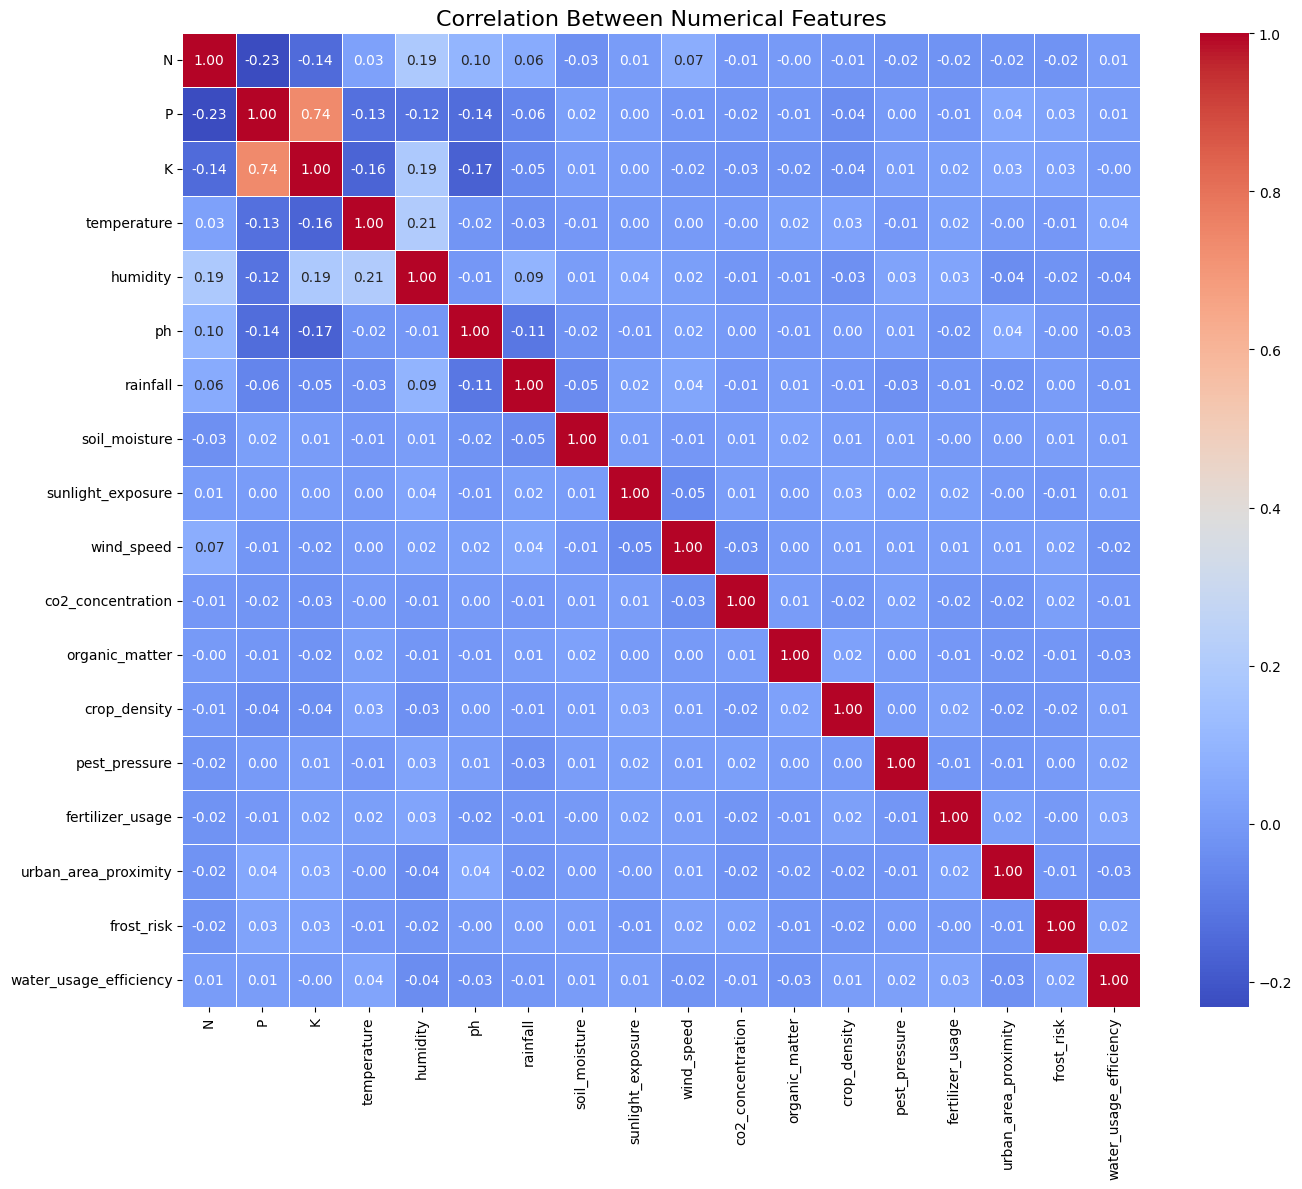

In [ ]:
plt.figure(figsize=(14, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Numerical Features", fontsize=16)

plt.tight_layout()
plt.show()

The correlation analysis shows that most numerical features have weak linear relationships with each other. The strongest relationship is between phosphorus and potassium, with a correlation of 0.74, indicating a strong positive association. Temperature and humidity have a weak positive correlation of 0.21, while nitrogen has weak negative correlations with phosphorus and potassium. Overall, there is limited multicollinearity among most of the features, with P and K being the main pair that stands out.

In [ ]:
print("=" * 60)
print("AVERAGE SOIL CONDITIONS BY CROP")
print("=" * 60)

crop_analysis = df.groupby('label')[
    ['N', 'P', 'K', 'ph']
].mean().round(2)

display(crop_analysis)

AVERAGE SOIL CONDITIONS BY CROP


,N,P,K,ph
label,,,,
apple,20.80,134.22,199.89,5.93
banana,100.23,82.01,50.05,5.98
blackgram,40.02,67.47,19.24,7.13
chickpea,40.09,67.79,79.92,7.34
coconut,21.98,16.93,30.59,5.98
coffee,101.20,28.74,29.94,6.79
cotton,117.77,46.24,19.56,6.91
grapes,23.18,132.53,200.11,6.03
jute,78.40,46.86,39.99,6.73


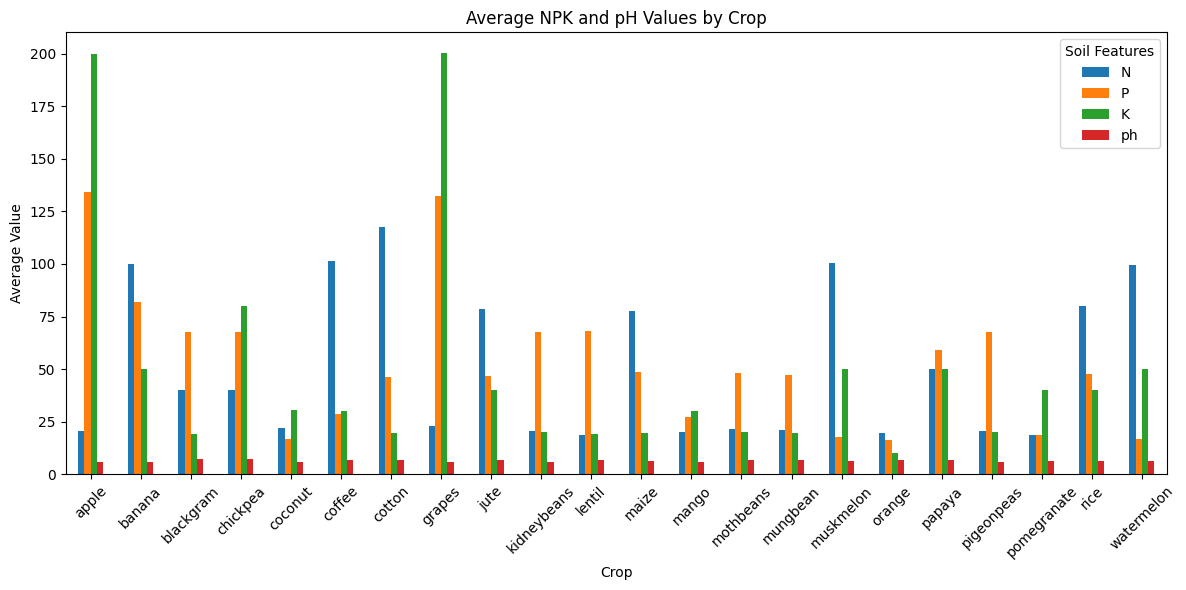

In [ ]:
crop_analysis.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Average NPK and pH Values by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend(title="Soil Features")

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("CROP DISTRIBUTION BY SOIL TYPE")
print("=" * 60)

crop_soil = pd.crosstab(
    df['label'],
    df['soil_type']
)

display(crop_soil)

CROP DISTRIBUTION BY SOIL TYPE


soil_type,1,2,3
label,,,
apple,29,40,31
banana,28,32,40
blackgram,44,34,22
chickpea,30,35,35
coconut,29,37,34
coffee,33,31,36
cotton,34,35,31
grapes,33,31,36
jute,30,28,42


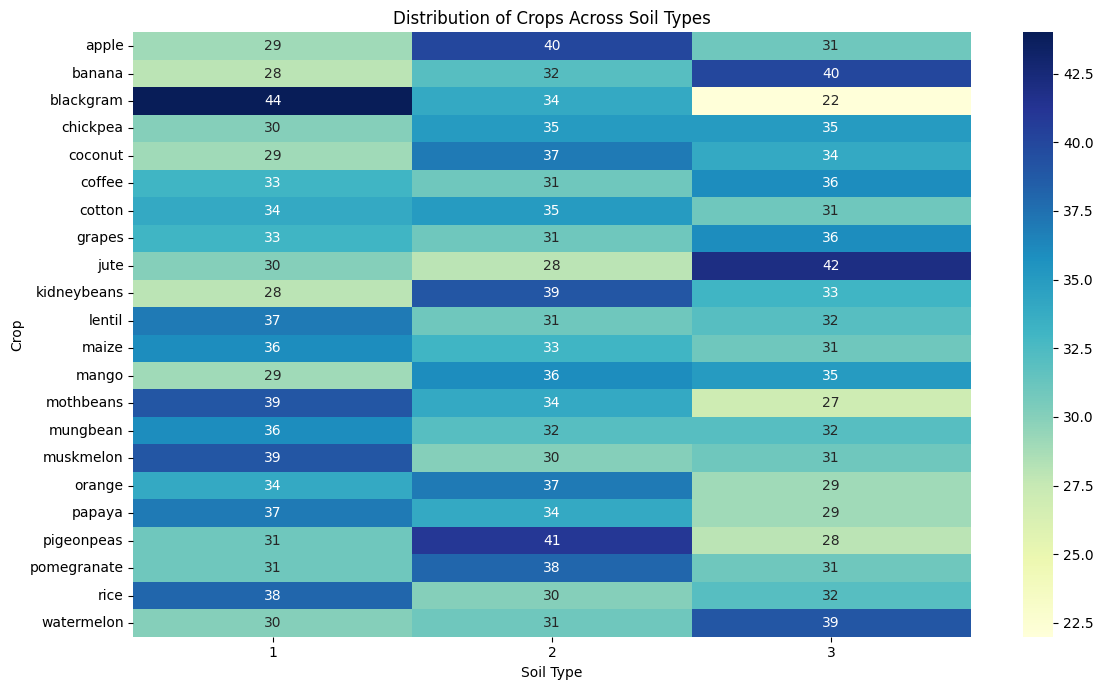

In [ ]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    crop_soil,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("Distribution of Crops Across Soil Types")
plt.xlabel("Soil Type")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

# EDA Summary

The structured dataset contains 2,200 observations and 23 columns, including
soil nutrients, environmental variables, management-related variables,
coded soil characteristics, and a crop label.

The dataset contains no missing values or duplicate rows. The crop label is
balanced across 22 crop classes, with 100 observations per class.

Correlation analysis shows that most numerical features have relatively weak
linear relationships, while phosphorus and potassium show the strongest
positive relationship (approximately 0.74).

The original `label` column represents crop recommendation rather than
nutrient-deficiency status. Since the dataset does not contain ground-truth
N, P, or K deficiency labels, the subsequent structured ML notebook derives
explicit proxy deficiency targets using dataset-relative nutrient thresholds.
These proxy labels should not be interpreted as laboratory-confirmed
agronomic deficiency measurements.